# Efficiency calculation

/tmp/ipykernel_7368/202403705.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


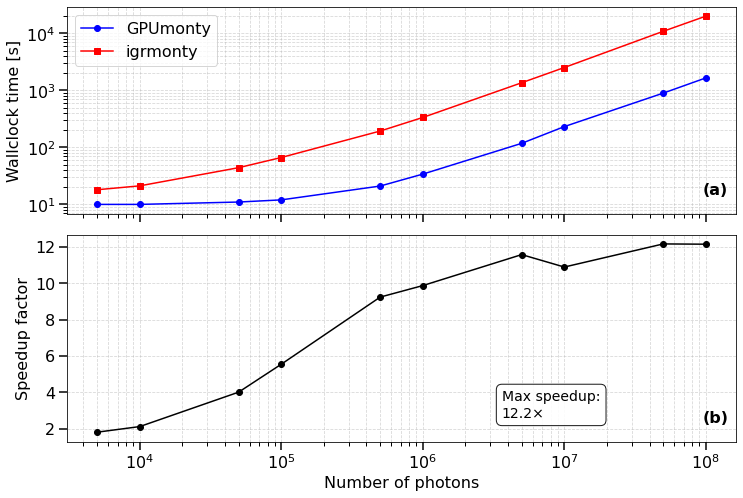

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Raw data
# -----------------------------

# GPUmonty timings (seconds)
gpumonty = {
    1e4: 10.0,
    1e5: 12.0,
    1e6: 34.0,
    1e7: 232.0,
    1e8: 1660.0,
    1e9: 11578.0,
    5e3: 10.0,
    5e4: 11.0,
    5e5: 21.0,
    5e6: 118.0,
    5e7: 898.0,
    5e8: 6539.0,
}

# igrmonty timings (seconds)
igrmonty = {
    1e3: 13.8996,
    1e4: 21.1566,
    1e5: 66.5263,
    1e6: 335.522,
    1e7: 2525.96,
    1e8: 20158.9,
    5e3: 18.0741,
    5e4: 44.0997,
    5e5: 193.942,
    5e6: 1365.4,
    5e7: 10918.5,
}

# -----------------------------
# Prepare matched data
# -----------------------------

# Use only photon counts present in both datasets
common_N = sorted(set(gpumonty.keys()) & set(igrmonty.keys()))

N = np.array(common_N)
t_gpu = np.array([gpumonty[n] for n in N])
t_igr = np.array([igrmonty[n] for n in N])

speedup = t_igr / t_gpu

# -----------------------------
# Plot
# -----------------------------

fig, axes = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={"hspace": 0.1}
)

# --- Panel 1: Wallclock time ---
ax = axes[0]
ax.loglog(N, t_gpu, marker='o', label='GPUmonty', color = 'blue')
ax.loglog(N, t_igr, marker='s', label='igrmonty', color = 'red')

ax.set_ylabel("Wallclock time [s]", fontsize = 16)
ax.legend(fontsize = 16)
ax.grid(True, which="both", ls="--", alpha=0.5)

# --- Panel 2: Speedup ---
ax = axes[1]
ax.semilogx(N, speedup, marker='o', color = 'black')

ax.set_xlabel("Number of photons", fontsize = 16)
ax.set_ylabel("Speedup factor", fontsize = 16)
ax.grid(True, which="both", ls="--", alpha=0.5)

# --- Panel labels ---
axes[0].text(
    0.95, 0.15, '(a)',
    transform=axes[0].transAxes,
    fontsize=16,
    va="top",
    ha="left",
    fontweight="bold"
)

axes[1].text(
    0.95, 0.15, "(b)",
    transform=axes[1].transAxes,
    fontsize=16,
    va="top",
    ha="left",
    fontweight="bold"
)

imax = np.argmax(speedup)
N_max = N[imax]
speedup_max = speedup[imax]

axes[1].text(
    0.65, 0.25,
    f"Max speedup:\n{speedup_max:.1f}×",
    transform=axes[1].transAxes,
    fontsize=14,
    ha="left",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="black",
        alpha=0.9
    )
)



for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=16, length=8, width=1.5)
    ax.tick_params(axis='both', which='minor', labelsize=16, length=4, width=1.0)

plt.tight_layout()
plt.savefig(
    "gpumonty_vs_igrmonty.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
